# Sepsis Case - Pipeline T-LEAF con grid search sulle frazioni di dati

Questo notebook usa esclusivamente il codice di `src/Sepsis_Case/` e il dataset
`Sepsis_Cases_Event_Log.xes`. La pipeline e organizzata come un **grid search
sulla quantita di dati**: ripete l'intero esperimento su frazioni crescenti di
tracce - **tutte, 1/2, 1/4, 1/8** - e per ognuna addestra e confronta tre
modelli di next-activity prediction:

1. **baseline** - solo cross-entropy;
2. **checker** - cross-entropy + massa di probabilita vietata dal DFA
   directly-follows (ramo checker-loss di T-LEAF);
3. **embedder** - cross-entropy + logic loss di T-LEAF `||q(A) - q(w_pred)||^2`
   su embedding appresi dei vincoli LTLf di precedenza.

L'obiettivo e mostrare **in quale regime di dati il metodo T-LEAF aiuta e in
quale diventa ridondante**: la conoscenza simbolica è più utile quando i dati
scarseggiano.

In [1]:
%matplotlib inline
import json
import random
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "src" / "Sepsis_Case").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Tutto il codice usato proviene dal pacchetto src/Sepsis_Case.
from src.Sepsis_Case.config import ExperimentConfig, TrainingConfig
from src.Sepsis_Case.data.xes import read_xes
from src.Sepsis_Case.data.prefixes import (
    ActivityVocabulary,
    extract_traces,
    make_data_loader,
    make_prefix_examples,
    split_traces,
)
from src.Sepsis_Case.pipeline.analysis import build_analysis_tables, summarise
from src.Sepsis_Case.pipeline.run_manager import create_next_run
from src.Sepsis_Case.process.automaton import ProcessDFA
from src.Sepsis_Case.process.ltl_constraints import mine_precedence_constraints
from src.Sepsis_Case.process.graph_encoding import FeatureSpace
from src.Sepsis_Case.learning.logic import (
    EmbeddingLogicLoss,
    build_allowed_mask,
    precedence_violation_rate,
)
from src.Sepsis_Case.learning.embedder import HierarchicalEmbedder
from src.Sepsis_Case.learning.embedder_training import (
    EmbedderConfig,
    evaluate_embedder,
    train_embedder,
)
from src.Sepsis_Case.learning.training import resolve_device, train_model
from src.Sepsis_Case.learning.evaluation import evaluate_model

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print("Pacchetto importato da:", ROOT / "src" / "Sepsis_Case")

Pacchetto importato da: C:\Users\Matteo\PycharmProjects\T-LEAF\src\Sepsis_Case


## 1. Configurazione

`FRACTIONS` definisce il grid search: le frazioni dell'insieme totale di tracce
su cui ripetere l'intera pipeline. I sottoinsiemi sono **annidati** (1/8 ⊂ 1/4 ⊂
1/2 ⊂ tutte), così la curva e una vera learning-curve. `QUICK_RUN = True` riduce
dati ed epoche per una verifica rapida.

In [2]:
QUICK_RUN = False

FRACTIONS = [1.0, 0.5, 0.25, 0.125, 0.0625]          # tutte, 1/2, 1/4, 1/8
GRID_ARCHITECTURES = ["gru", "lstm"]                      # la logic loss embedder e onerosa: una sola architettura
BASE_MAX_CASES = 200 if QUICK_RUN else None    # None = intero dataset
TARGET_EPOCHS = 4 if QUICK_RUN else 15
EMBEDDER_EPOCHS = 3 if QUICK_RUN else 5
LOGIC_WEIGHT = 0.5

DATA_PATH = ROOT / "datasets/Sepsis_Case/Sepsis_Cases_Event_Log.xes"
run_paths = create_next_run(ROOT / "runs", "Sepsis_Case_TLEAF_Grid")
OUTPUT_DIR, MODEL_DIR = run_paths.root, run_paths.models

config = ExperimentConfig(
    seed=42,
    training=TrainingConfig(
        epochs=TARGET_EPOCHS,
        device="auto",
        logic_weight=LOGIC_WEIGHT,
        early_stopping_patience=4,
        early_stopping_min_epochs=2 if QUICK_RUN else 5,
    ),
)
device = resolve_device(config.training.device)
print("Dataset    :", DATA_PATH)
print("Run dir    :", OUTPUT_DIR)
print("Device     :", device, "| QUICK_RUN:", QUICK_RUN)
print("Frazioni   :", FRACTIONS, "| architetture:", GRID_ARCHITECTURES)

Dataset    : C:\Users\Matteo\PycharmProjects\T-LEAF\datasets\Sepsis_Case\Sepsis_Cases_Event_Log.xes
Run dir    : C:\Users\Matteo\PycharmProjects\T-LEAF\runs\Sepsis_Case_TLEAF_Grid_run_3
Device     : cuda | QUICK_RUN: False
Frazioni   : [1.0, 0.5, 0.25, 0.125, 0.0625] | architetture: ['gru', 'lstm']


## 2. Caricamento del log e analisi esplorativa

Carichiamo il log una sola volta, costruiamo le tracce e un ordine casuale (ma
fissato dal seed) dei casi: le frazioni del grid prenderanno i primi `f * N`
casi di questo ordine, ottenendo sottoinsiemi annidati.

In [3]:
events = read_xes(DATA_PATH, max_cases=BASE_MAX_CASES)
tables = build_analysis_tables(events)
summary = summarise(tables, DATA_PATH)
print(json.dumps(summary, indent=2))

all_traces = extract_traces(events)
ordered_case_ids = sorted(all_traces)
random.Random(config.seed).shuffle(ordered_case_ids)
print(f"\nCasi totali disponibili: {len(ordered_case_ids)}")
print("Attivita piu frequenti:")
display(tables.activities.head(8))

{
  "input": "C:\\Users\\Matteo\\PycharmProjects\\T-LEAF\\datasets\\Sepsis_Case\\Sepsis_Cases_Event_Log.xes",
  "cases": 1050,
  "events": 15214,
  "activities": 16,
  "variants": 846,
  "groups": 26,
  "events_per_case": {
    "mean": 14.48952380952381,
    "median": 13.0,
    "min": 3,
    "max": 185
  },
  "duration_hours": {
    "mean": 683.2594277777778,
    "median": 128.24125,
    "min": 0.03388888888888889,
    "max": 10135.774722222222
  },
  "outcomes": {
    "return_er_cases": 294,
    "admission_ic_cases": 110,
    "release_cases": 782
  },
  "most_common_activity": "Leucocytes",
  "most_common_variant_cases": 35
}

Casi totali disponibili: 1050
Attivita piu frequenti:


,activity,count
0,Leucocytes,3383
1,CRP,3262
2,LacticAcid,1466
3,Admission NC,1182
4,ER Triage,1053
5,ER Registration,1050
6,ER Sepsis Triage,1049
7,IV Antibiotics,823


## 3. Disegno sperimentale

Per ogni frazione di dati la funzione `run_fraction` esegue **l'intera pipeline**:
split per caso, vocabolario, DFA directly-follows, estrazione dei vincoli LTLf di
precedenza, addestramento dell'embedder gerarchico (qe+qm) con triplet loss, e
addestramento dei tre modelli target (baseline/checker/embedder) con lo stesso
seed. Restituisce le metriche sul test set, incluse due misure di conformita:
`forbidden_mass` (metrica del checker) e `precedence_violation_rate` (metrica
dell'embedder).

In [4]:
def run_fraction(fraction, architecture,
                 target_epochs=TARGET_EPOCHS, embedder_epochs=EMBEDDER_EPOCHS, seed=42):
    # Sottoinsieme annidato di tracce: i primi f*N casi dell'ordine casuale.
    n_pool = max(3, int(round(fraction * len(ordered_case_ids))))
    sub_ids = ordered_case_ids[:n_pool]
    sub_traces = {cid: all_traces[cid] for cid in sub_ids}

    splits = split_traces(sub_traces, config.data.validation_fraction,
                          config.data.test_fraction, seed=seed)
    voc = ActivityVocabulary.from_traces(splits.train.values())
    unseen = {a for part in (splits.validation, splits.test)
              for tr in part.values() for a in tr if a not in voc.class_to_id}
    if unseen:
        voc = ActivityVocabulary.from_traces(sub_traces.values())
    ex = {n: make_prefix_examples(p, voc) for n, p in [
        ("train", splits.train), ("validation", splits.validation), ("test", splits.test)]}
    ld = {n: make_data_loader(ex[n], voc, config.data.batch_size, shuffle=(n == "train")) for n in ex}

    automaton = ProcessDFA.from_traces(splits.train.values())
    mask = build_allowed_mask(automaton, voc)

    n_train = len(splits.train)
    min_support = max(3, n_train // 10)  # soglia adattiva alla dimensione
    cons = mine_precedence_constraints(splits.train.values(), min_support=min_support,
                                       min_confidence=0.95, max_constraints=15)

    emb_logic = None
    if cons:
        space = FeatureSpace.create(voc.activities, prop_dim=50, node_dim=100, seed=seed, device=device)
        emb = HierarchicalEmbedder(aggregation="random_walk", normalize=False, meta_layers=2).to(device)
        train_embedder(emb, space, cons, voc.activities,
                       EmbedderConfig(epochs=embedder_epochs, triplets_per_constraint=12,
                                      margin=5.0, learning_rate=2e-3, seed=seed),
                       device=device, verbose=False)
        emb_logic = EmbeddingLogicLoss(emb, space, cons, voc, max_examples=10, max_constraints=3)

    modes = {
        "baseline": dict(use_logic=False, logic_mode="checker", embedding_logic=None),
        "checker": dict(use_logic=True, logic_mode="checker", embedding_logic=None),
    }
    if emb_logic is not None:
        modes["embedder"] = dict(use_logic=True, logic_mode="embedder", embedding_logic=emb_logic)

    cfg = replace(config, training=replace(config.training, epochs=target_epochs))
    rows = []
    for mode, kwargs in modes.items():
        weight = 0.0 if mode == "baseline" else LOGIC_WEIGHT
        rc = replace(cfg, training=replace(cfg.training, logic_weight=weight))
        tr = train_model(architecture, voc, ld["train"], ld["validation"], mask, rc,
                         MODEL_DIR / f"f{fraction}_{architecture}_{mode}.pt", **kwargs)
        ev = evaluate_model(tr.model, ld["test"], mask.to(device), device, top_k=config.training.top_k)
        pvr = precedence_violation_rate(tr.model, ld["test"], cons, voc, device) if cons else float("nan")
        rows.append({"fraction": fraction, "architecture": architecture, "n_pool": n_pool, "n_train_cases": n_train,
                     "n_constraints": len(cons), "logic_mode": mode,
                     "accuracy": ev.accuracy, "macro_f1": ev.macro_f1,
                     "top_k_accuracy": ev.top_k_accuracy, "forbidden_mass": ev.forbidden_mass,
                     "violation_rate": ev.violation_rate, "precedence_violation_rate": pvr,
                     "best_epoch": tr.best_epoch})
    return rows

## 4. Esecuzione del grid search

Il giro completo e oneroso (per ogni frazione: un embedder + tre modelli target;
la frazione `1.0` e la piu lenta). Con `QUICK_RUN = True` finisce in pochi minuti.

In [5]:


grid_rows = []
for fraction in FRACTIONS:
    for architecture in GRID_ARCHITECTURES:
        print(f"\n===================== FRAZIONE {fraction} | ARCHITECTURE {architecture} =====================")
        rows = run_fraction(fraction, architecture)
        grid_rows += rows
        for r in rows:
            print(f"   {r['logic_mode']:9s} n_train={r['n_train_cases']:>4} "
                  f"vincoli={r['n_constraints']:>2} acc={r['accuracy']:.4f} "
                  f"prec_viol={r['precedence_violation_rate']:.5f} "
                  f"forbidden={r['forbidden_mass']:.5f}")

grid = pd.DataFrame(grid_rows)
grid.to_csv(OUTPUT_DIR / "grid_search_fractions.csv", index=False)
display(grid.style.format(precision=4))


===================== FRAZIONE 1.0 | ARCHITECTURE gru =====================
   baseline  n_train= 735 vincoli=15 acc=0.6762 prec_viol=0.00046 forbidden=0.00276
   checker   n_train= 735 vincoli=15 acc=0.6744 prec_viol=0.00046 forbidden=0.00255
   embedder  n_train= 735 vincoli=15 acc=0.6716 prec_viol=0.00046 forbidden=0.00294

===================== FRAZIONE 1.0 | ARCHITECTURE lstm =====================
   baseline  n_train= 735 vincoli=15 acc=0.6711 prec_viol=0.00046 forbidden=0.00299
   checker   n_train= 735 vincoli=15 acc=0.6716 prec_viol=0.00046 forbidden=0.00238
   embedder  n_train= 735 vincoli=15 acc=0.6651 prec_viol=0.00046 forbidden=0.00374

===================== FRAZIONE 0.5 | ARCHITECTURE gru =====================
   baseline  n_train= 367 vincoli=15 acc=0.6726 prec_viol=0.00000 forbidden=0.00516
   checker   n_train= 367 vincoli=15 acc=0.6708 prec_viol=0.00000 forbidden=0.00393
   embedder  n_train= 367 vincoli=15 acc=0.6487 prec_viol=0.00000 forbidden=0.00754

===========

,fraction,architecture,n_pool,n_train_cases,n_constraints,logic_mode,accuracy,macro_f1,top_k_accuracy,forbidden_mass,violation_rate,precedence_violation_rate,best_epoch
0,1.0000,gru,1050,735,15,baseline,0.6762,0.4809,0.9352,0.0028,0.0000,0.0005,15
1,1.0000,gru,1050,735,15,checker,0.6744,0.4928,0.9296,0.0025,0.0000,0.0005,12
2,1.0000,gru,1050,735,15,embedder,0.6716,0.4783,0.9199,0.0029,0.0000,0.0005,15
3,1.0000,lstm,1050,735,15,baseline,0.6711,0.4789,0.9310,0.0030,0.0000,0.0005,15
4,1.0000,lstm,1050,735,15,checker,0.6716,0.4881,0.9305,0.0024,0.0000,0.0005,13
5,1.0000,lstm,1050,735,15,embedder,0.6651,0.4703,0.9189,0.0037,0.0000,0.0005,13
6,0.5000,gru,525,367,15,baseline,0.6726,0.5249,0.9265,0.0052,0.0009,0.0000,15
7,0.5000,gru,525,367,15,checker,0.6708,0.5200,0.9283,0.0039,0.0000,0.0000,15
8,0.5000,gru,525,367,15,embedder,0.6487,0.4956,0.8929,0.0075,0.0000,0.0000,11
9,0.5000,lstm,525,367,15,baseline,0.6788,0.5220,0.9265,0.0054,0.0000,0.0000,15


## 5. Analisi: curve in funzione della quantita di dati

Architetture nel grid: ['gru', 'lstm']

precedence_violation_rate (media su 2 architettura/e):


logic_mode,baseline,checker,embedder
n_train_cases,,,
46,0.00000,0.00000,0.00000
91,0.00161,0.00161,0.00000
183,0.00200,0.00200,0.00200
367,0.00000,0.00000,0.00000
735,0.00046,0.00046,0.00046



forbidden_mass (media su 2 architettura/e):


logic_mode,baseline,checker,embedder
n_train_cases,,,
46,0.06177,0.05208,0.06786
91,0.02504,0.01952,0.02595
183,0.01393,0.01085,0.01567
367,0.00526,0.00411,0.00820
735,0.00287,0.00246,0.00334



accuracy (media su 2 architettura/e):


logic_mode,baseline,checker,embedder
n_train_cases,,,
46,0.59375,0.58984,0.54297
91,0.61452,0.60968,0.59839
183,0.62774,0.62974,0.63373
367,0.67566,0.67611,0.63584
735,0.67369,0.67300,0.66836


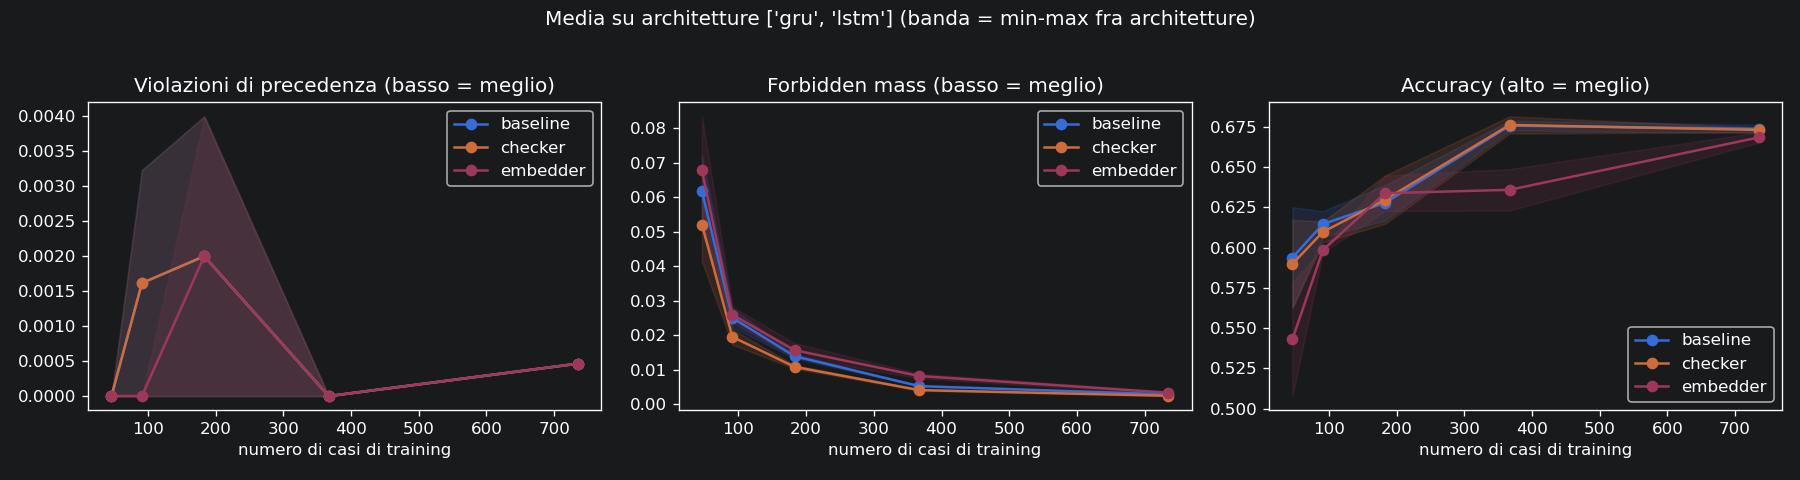

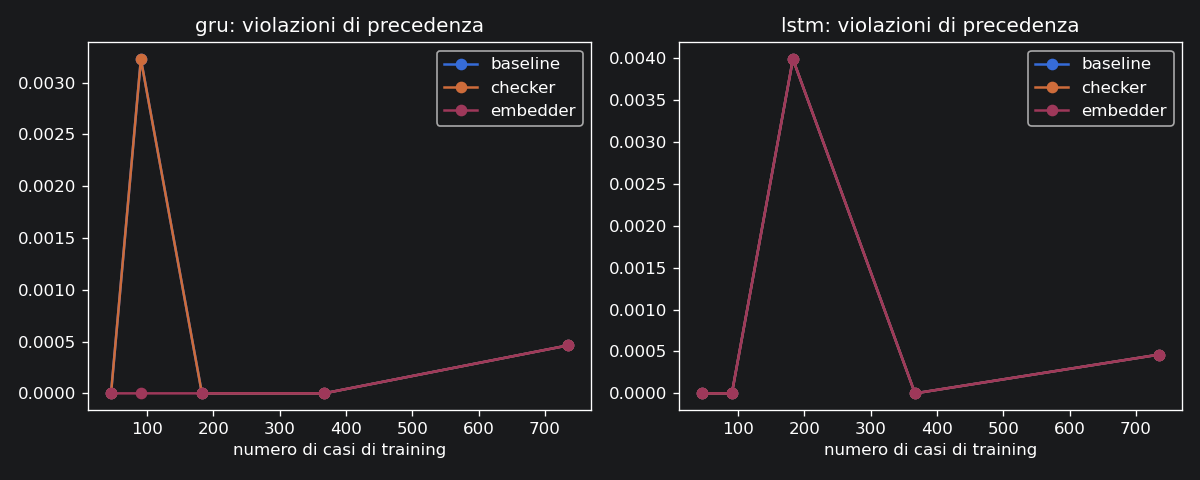

In [6]:
# Con piu architetture, aggreghiamo (media) sulle architetture per ogni
# coppia (frazione, modo); cosi l'indice e unico e le curve restano leggibili.
order = sorted(grid["n_train_cases"].unique())
modes_present = [m for m in ["baseline", "checker", "embedder"] if m in set(grid["logic_mode"])]
architectures = sorted(grid["architecture"].unique())
print(f"Architetture nel grid: {architectures}")

# Tabelle: media sulle architetture (indice = casi di training, colonne = modi).
for metric in ["precedence_violation_rate", "forbidden_mass", "accuracy"]:
    print(f"\n{metric} (media su {len(architectures)} architettura/e):")
    pivot = (grid.groupby(["n_train_cases", "logic_mode"])[metric].mean()
             .unstack("logic_mode").reindex(index=order, columns=modes_present))
    display(pivot.style.format(precision=5))

# Curve aggregate: linea = media sulle architetture, banda = min-max fra architetture.
g_mean = grid.groupby(["n_train_cases", "logic_mode"]).mean(numeric_only=True)
g_min = grid.groupby(["n_train_cases", "logic_mode"]).min(numeric_only=True)
g_max = grid.groupby(["n_train_cases", "logic_mode"]).max(numeric_only=True)

def series(table, metric, mode):
    return [table.loc[(n, mode), metric] if (n, mode) in table.index else np.nan for n in order]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for (metric, title), ax in zip([
    ("precedence_violation_rate", "Violazioni di precedenza (basso = meglio)"),
    ("forbidden_mass", "Forbidden mass (basso = meglio)"),
    ("accuracy", "Accuracy (alto = meglio)"),
], axes):
    for mode in modes_present:
        line, = ax.plot(order, series(g_mean, metric, mode), marker="o", label=mode)
        if len(architectures) > 1:
            ax.fill_between(order, series(g_min, metric, mode), series(g_max, metric, mode),
                            alpha=0.15, color=line.get_color())
    ax.set_xlabel("numero di casi di training"); ax.set_title(title); ax.legend()
band = " (banda = min-max fra architetture)" if len(architectures) > 1 else ""
fig.suptitle(f"Media su architetture {architectures}{band}")
fig.tight_layout(rect=(0, 0, 1, 0.95))
curve_path = OUTPUT_DIR / "grid_curves.png"
fig.savefig(curve_path, dpi=120); plt.close(fig)
display(Image(filename=str(curve_path)))

# Dettaglio per architettura sulla metrica chiave dell'embedder.
fig2, axes2 = plt.subplots(1, len(architectures), figsize=(5 * len(architectures), 4), squeeze=False)
for ax, arch in zip(axes2[0], architectures):
    sub_arch = grid[grid.architecture == arch]
    for mode in modes_present:
        s = (sub_arch[sub_arch.logic_mode == mode]
             .groupby("n_train_cases")["precedence_violation_rate"].mean().reindex(order))
        ax.plot(order, s.values, marker="o", label=mode)
    ax.set_title(f"{arch}: violazioni di precedenza")
    ax.set_xlabel("numero di casi di training"); ax.legend()
fig2.tight_layout()
curve2_path = OUTPUT_DIR / "grid_curves_per_arch.png"
fig2.savefig(curve2_path, dpi=120); plt.close(fig2)
display(Image(filename=str(curve2_path)))

In [7]:
# Verdetto automatico (media sulle architetture): dove l'embedder (T-LEAF)
# aiuta vs e ridondante, frazione per frazione.
print("=" * 76)
print(f"VERDETTO PER FRAZIONE - media su {sorted(grid['architecture'].unique())} (delta embedder - baseline)")
print("=" * 76)
helps = []
for fraction in sorted(grid["fraction"].unique(), reverse=True):
    sub = grid[grid.fraction == fraction]
    if "embedder" not in set(sub["logic_mode"]):
        continue
    n_train = int(sub["n_train_cases"].iloc[0])
    base_prec = sub[sub.logic_mode == "baseline"]["precedence_violation_rate"].mean()
    emb_prec = sub[sub.logic_mode == "embedder"]["precedence_violation_rate"].mean()
    base_acc = sub[sub.logic_mode == "baseline"]["accuracy"].mean()
    emb_acc = sub[sub.logic_mode == "embedder"]["accuracy"].mean()
    d_prec = emb_prec - base_prec
    d_acc = emb_acc - base_acc
    flag = "AIUTA" if d_prec < -1e-5 else ("ridondante" if abs(d_prec) <= 1e-5 else "peggiora")
    if d_prec < -1e-5:
        helps.append(fraction)
    print(f"  frazione {fraction:<7} (n_train={n_train:>4}): "
          f"viol baseline={base_prec:.5f} -> delta={d_prec:+.5f} [{flag}], delta_acc={d_acc:+.4f}")
print("-" * 76)
if helps:
    print(f"L'embedder (T-LEAF) RIDUCE le violazioni di precedenza nelle frazioni: {helps}")
    print("=> il vantaggio si concentra nel regime a dati scarsi, come previsto dal paper.")
else:
    print("In nessuna frazione l'embedder riduce (in media) le violazioni: con questi dati la")
    print("baseline e gia conforme. Prova frazioni piu piccole o vincoli piu difficili.")
print("=" * 76)

VERDETTO PER FRAZIONE - media su ['gru', 'lstm'] (delta embedder - baseline)
  frazione 1.0     (n_train= 735): viol baseline=0.00046 -> delta=+0.00000 [ridondante], delta_acc=-0.0053
  frazione 0.5     (n_train= 367): viol baseline=0.00000 -> delta=+0.00000 [ridondante], delta_acc=-0.0398
  frazione 0.25    (n_train= 183): viol baseline=0.00200 -> delta=+0.00000 [ridondante], delta_acc=+0.0060
  frazione 0.125   (n_train=  91): viol baseline=0.00161 -> delta=-0.00161 [AIUTA], delta_acc=-0.0161
  frazione 0.0625  (n_train=  46): viol baseline=0.00000 -> delta=+0.00000 [ridondante], delta_acc=-0.0508
----------------------------------------------------------------------------
L'embedder (T-LEAF) RIDUCE le violazioni di precedenza nelle frazioni: [0.125]
=> il vantaggio si concentra nel regime a dati scarsi, come previsto dal paper.


## 6. Conclusioni

- Il **grid search sulle frazioni** mostra la dipendenza dal regime di dati: a
  sinistra (poche tracce) la baseline viola di piu i vincoli e la logic loss ha
  spazio per aiutare; a destra (tutte le tracce) la baseline impara la struttura
  del processo da sola e i tre modi convergono.
- Il ramo **embedder** va letto sulla `precedence_violation_rate` (la sua
  conoscenza), il ramo **checker** sulla `forbidden_mass`.
- Il verdetto automatico indica, frazione per frazione, dove T-LEAF aiuta e dove
  diventa ridondante.

Limiti dichiarati (coerenti con `src/Sepsis_Case`): vincoli di sola precedenza;
vincoli multipli combinati sommando le distanze per-DFA; feature di attivita
fisse casuali; embedder addestrato congiuntamente (qe+qm). Per un confronto piu
robusto si puo aggiungere una seconda architettura a `GRID_ARCHITECTURE` o
mediare su piu semi.